In [2]:
%pip install powerlaw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 6.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import numpy as np
import powerlaw
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm


In [96]:
# --- 1. Data Generation (Simulation) ---
def generate_data(num_rows, share_zeros, distribution_dict, seed):
    np.random.seed(seed) # for reproducibility

    # Part 1: Zeros
    num_zeros = int(num_rows * share_zeros)
    zeros = np.zeros(num_zeros)
    num_non_zeros = num_rows - num_zeros

    # Part 2: Non-Zeros based on Distribution
    dist_type = distribution_dict['distribution']

    if dist_type == 'lognormal':
        # NumPy uses 'mean' and 'sigma'
        non_zeros_raw = np.random.lognormal(
            mean=distribution_dict['mu'],
            sigma=distribution_dict['sigma'],
            size=num_non_zeros
        )

    elif dist_type == 'exponential':
        # NumPy uses 'scale' (1/lambda)
        non_zeros_raw = np.random.exponential(
            scale=distribution_dict['scale'],
            size=num_non_zeros
        )
        
    elif dist_type == 'powerlaw':
        # Using Pareto transformation: (Pareto + 1) * xmin
        alpha = distribution_dict['alpha']
        xmin = distribution_dict['xmin']
        non_zeros_raw = (np.random.pareto(a=alpha, size=num_non_zeros) + 1) * xmin
    
    elif dist_type == 'weibull':
        # NumPy weibull only takes 'a' (shape). Scale is applied manually.
        shape = distribution_dict['shape']
        scale = distribution_dict['scale']
        non_zeros_raw = np.random.weibull(a=shape, size=num_non_zeros) * scale

    else:
        raise ValueError(f"Invalid distribution specified: {dist_type}")
        
    # Filter out values less than 10 as per your original logic
    non_zeros_filtered = non_zeros_raw[non_zeros_raw >= 10]

    # Print internal stats for the non-zero portion
    if len(non_zeros_filtered) > 0:
        print(f"--- {dist_type.upper()} Distribution Diagnostics ---")
        print(f"Simulated non-zero max value: {np.max(non_zeros_filtered):.2f}")
        print(f"Simulated non-zero 90th percentile: {np.percentile(non_zeros_filtered, 90):.2f}")
        print(f"Simulated non-zero 50th percentile (median): {np.median(non_zeros_filtered):.2f}")
    else:
        print(f"Warning: All generated {dist_type} values were filtered out by the >= 10 threshold.")

    # Combine zeros and non-zeros
    revenue_data = np.concatenate((zeros, non_zeros_filtered))

    # Create a Pandas DataFrame
    df = pd.DataFrame({'revenue': revenue_data})

    print(f"\nTotal simulated data points: {len(df)}")
    print(f"Number of zeros: {df['revenue'].eq(0).sum()}")
    print(f"Number of non-zeros: {df['revenue'].gt(0).sum()}")
    
    # Final Descriptive Stats
    non_zero_df = df[df['revenue'] > 0]
    if not non_zero_df.empty:
        print(f"Descriptive statistics for non-zero revenue:\n{non_zero_df['revenue'].describe()}")
    
    return df

log_normal_dict = { # Non-zero, skewed, fat-tailed (Log-Normal)
    'distribution': 'lognormal',
    'mu': 3.5,
    'sigma': 1.8
}

exponential_dict = { # always has finite variance
    'distribution': 'exponential',
    'scale': 20
}

powerlaw_dict = { # alpha between 1 and 2 has finite mean and infinite variance. >2 both are finite
    'distribution': 'powerlaw',
    'xmin': 5,
    'alpha': 1.1
}
weibull_dict = { # always finite variance. Heavy tail with shape < 1
    'distribution': 'weibull',
    'scale': 25,
    'shape': 0.4
}

df = generate_data(
    num_rows=5000,
    share_zeros=0.9,
    distribution_dict=log_normal_dict,
    seed=42
)

--- LOGNORMAL Distribution Diagnostics ---
Simulated non-zero max value: 34027.24
Simulated non-zero 90th percentile: 473.70
Simulated non-zero 50th percentile (median): 58.75

Total simulated data points: 4870
Number of zeros: 4500
Number of non-zeros: 370
Descriptive statistics for non-zero revenue:
count      370.000000
mean       296.696978
std       1852.455492
min         10.062185
25%         26.903158
50%         58.750424
75%        146.124615
max      34027.240813
Name: revenue, dtype: float64



Analyzing 370 non-zero revenue points.


Text(0, 0.5, 'Frequency')

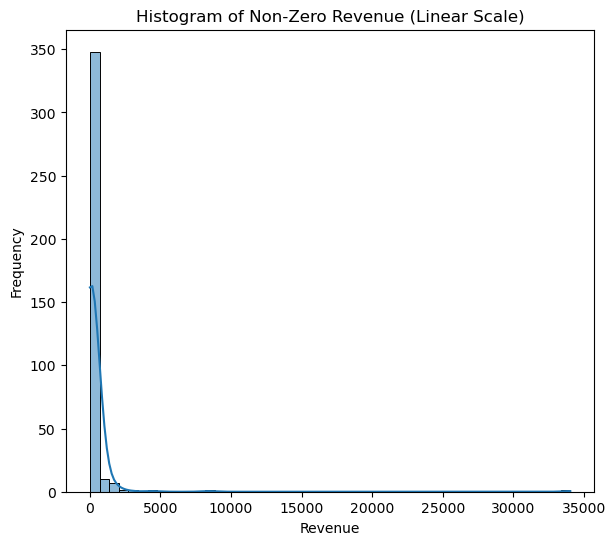

In [97]:
# --- 2. Initial Data Preparation and Visual Inspection ---

# Filter out zeros for tail analysis
non_zero_revenue = df[df['revenue'] > 0]['revenue'].values
print(f"\nAnalyzing {len(non_zero_revenue)} non-zero revenue points.")

# Visualizations:
plt.figure(figsize=(15, 6))

# Histogram (linear scale)
plt.subplot(1, 2, 1)
sns.histplot(non_zero_revenue, bins=50, kde=True)
plt.title('Histogram of Non-Zero Revenue (Linear Scale)')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_36611/2779742470.py:9: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('P($X \geq x$)', fontsize=12)


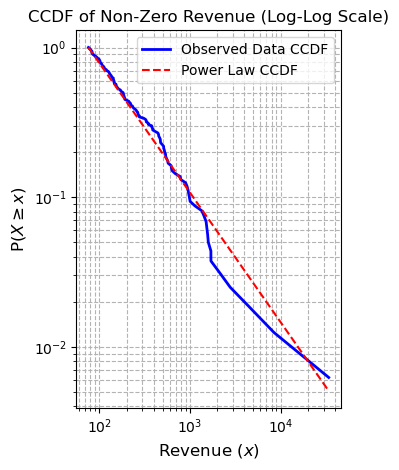

In [98]:
# Complementary Cumulative Distribution Function (CCDF) on log-log scale
plt.subplot(1, 2, 2)
fit_prelim = powerlaw.Fit(non_zero_revenue, discrete=False, verbose=False) # Use a preliminary fit just for plotting CCDF
fit_prelim.plot_ccdf(ax=plt.gca(), linewidth=2, color='blue', label='Observed Data CCDF')
fit_prelim.power_law.plot_ccdf(ax=plt.gca(), linestyle='--', color='red', label='Power Law CCDF')

plt.title('CCDF of Non-Zero Revenue (Log-Log Scale)')
plt.xlabel('Revenue ($x$)', fontsize=12)
plt.ylabel('P($X \geq x$)', fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')

plt.tight_layout()
plt.show()

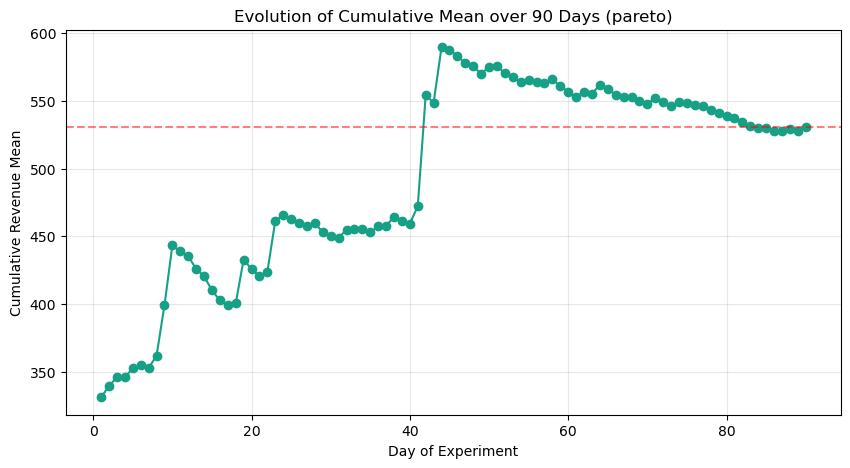

In [99]:
def simulate_daily_convergence(days=30, obs_per_day=100, dist_type='lognormal', seed=42):
    """
    Simulates daily data collection and plots the evolution of the mean.
    """
    daily_means = []
    cumulative_data = []
    np.random.seed(seed)
    for day in range(1, days + 1):
        if dist_type == 'lognormal':
            # High variance but finite
            day_data = np.random.lognormal(mean=2, sigma=1.5, size=obs_per_day)
        elif dist_type == 'pareto':
            # Infinite variance (alpha=1.01)
            day_data = (np.random.pareto(1.01, size=obs_per_day) + 1) * 50
        
        cumulative_data.extend(day_data)
        daily_means.append(np.mean(cumulative_data))

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, days + 1), daily_means, marker='o', linestyle='-', color='#16a085')
    plt.axhline(y=daily_means[-1], color='r', linestyle='--', alpha=0.5)
    plt.title(f'Evolution of Cumulative Mean over {days} Days ({dist_type})')
    plt.xlabel('Day of Experiment')
    plt.ylabel('Cumulative Revenue Mean')
    plt.grid(alpha=0.3)
    plt.show()

# Run it for the "dangerous" Pareto distribution
simulate_daily_convergence(days=90, obs_per_day=1000, dist_type='pareto', seed=2)

In [100]:
# --- 3. Power-Law Fitting & x_min Estimation ---
print("\n--- Step 3: Fitting Power Law and Estimating x_min ---")
fit = powerlaw.Fit(non_zero_revenue, discrete=False, verbose=True)

alpha = fit.power_law.alpha
xmin = fit.power_law.xmin
KS = fit.power_law.D

print(f"\nEstimated Power Law Exponent (alpha): {alpha:.4f}")
print(f"Estimated Power Law x_min: {xmin:.2f}")

if alpha <= 2:
    print(f"  Interpretation: Since alpha ({alpha:.2f}) <= 2, the fitted power law suggests infinite variance.")
elif alpha > 2 and alpha < 3:
    print(f"  Interpretation: Since 2 < alpha ({alpha:.2f}) < 3, the fitted power law suggests finite variance but infinite skewness.")
else: # alpha >= 3
    print(f"  Interpretation: Since alpha ({alpha:.2f}) >= 3, the fitted power law suggests finite variance and finite skewness.")


--- Step 3: Fitting Power Law and Estimating x_min ---
Calculating best minimal value for power law fit


Fitting xmin: 100%|█████████████████████████| 368/368 [00:00<00:00, 9741.88it/s]


Estimated Power Law Exponent (alpha): 1.8655
Estimated Power Law x_min: 76.08
  Interpretation: Since alpha (1.87) <= 2, the fitted power law suggests infinite variance.


**Recall:** the estimates in this block above are valid *only if* the data truly follows a power law distribution.

In [101]:
def calculate_powerlaw_gof_p_value(data, fit, num_bootstraps=2500, discrete=False, seed=None):
    """
    Calculates the p-value for the power-law goodness-of-fit
    using the bootstrapping method described in Clauset, Newman, and Moore (2009).

    Args:
        data (numpy.ndarray): The observed data to be fitted. Must be strictly positive.
        fit (powerlaw.Fit): The fitted powerlaw object.
        num_bootstraps (int): The number of synthetic datasets to generate.
        discrete (bool): Whether the data is discrete or continuous.
        seed (int): Seed for the random number generator.

    Returns:
        float: The p-value for the power-law goodness-of-fit.
        list: A list of D statistics from the synthetic datasets.
    """
    if not isinstance(data, np.ndarray):
        data = np.array(data)

    if np.any(data <= 0):
        raise ValueError("Data must be strictly positive for power-law fitting.")
    
    # The size of synthetic data should be the same as the observed data >= xmin
    # This is crucial for consistency with CNS paper's methodology
    data_above_xmin = data[data >= fit.power_law.xmin]
    n_for_gof = len(data_above_xmin)

    print(f"\nPerforming {num_bootstraps} bootstraps...")
    # Seed numpy for reproducibility of the bootstrap samples
    if seed is not None:
        np.random.seed(seed) 
    
    # Step 2: Generate synthetic datasets and calculate their KS statistics
    synthetic_D_values = []
    
    # Use tqdm for a progress bar as this can take time
    for _ in tqdm.trange(num_bootstraps, desc="Bootstrapping"):
        # Generate a synthetic dataset from the *fitted* power law
        # Use fit_obs.power_law.generate_random() as it handles the distribution type (discrete/continuous)
        synthetic_data = fit.power_law.generate_random(n_for_gof)

        # Fit a new power law to the synthetic data, but crucially,
        # FIX the xmin to the original fitted xmin (as per CNS, Section 3, steps 2-4)
        try:
            fit_synthetic = powerlaw.Fit(
                synthetic_data,
                xmin=fit.power_law.xmin,        # FIX xmin to the original fitted xmin
                #fixed_xmin=True,      # Crucial: tell the fit to use this fixed xmin
                discrete=discrete,
                verbose=False         # Keep quiet for the inner loop
            )
            
            # The D attribute of this synthetic fit is the KS statistic
            # between the synthetic data and the power law with the fixed xmin.
            D_synthetic = fit_synthetic.power_law.D
            synthetic_D_values.append(D_synthetic)
        except Exception as e:
            # Handle cases where a fit might fail for a synthetic dataset (rare but possible for edge cases)
            print(f"  Warning: Fit failed for a synthetic dataset: {e}. Skipping this sample.")
            continue # Skip this sample if fit fails

    # Step 3: Calculate the p-value
    # The p-value is the fraction of synthetic D values that are >= D_obs
    count_greater_or_equal = np.sum(np.array(synthetic_D_values) >= fit.power_law.D)
    
    # Ensure no division by zero if all fits failed
    p_value = count_greater_or_equal / len(synthetic_D_values) if len(synthetic_D_values) > 0 else 0

    print(f"\nBootstrapping complete. Performed {len(synthetic_D_values)} successful bootstraps.")
    if p_value > 0.1:
        print(f"  Interpretation: p-value ({p_value:.2f}) > 0.1. The data above x_min is consistent with a power law distribution.")
    else:
        print(f"  Interpretation: p-value ({p_value:.2f}) <= 0.1. The data above x_min is NOT consistent with a power law distribution.")
    return p_value, synthetic_D_values

There is one subtle point regarding the Clauset et al. (2009) methodology that I should mention, as it often trips people up when writing these functions:In the paper (Section 3), for a truly rigorous $p$-value, the synthetic fits are actually supposed to re-estimate $x_{min}$ for every synthetic dataset, rather than fixing it to the original $x_{min}$.
- Fixed $x_{min}$ (What you have): This tests if your data matches the specific power law model you found. It is a faster and more "conservative" test.
- Variable $x_{min}$ (Paper standard): The paper suggests letting powerlaw.Fit find the best $x_{min}$ for each synthetic sample. This accounts for the fact that the $x_{min}$ estimation itself is a source of variance.

If you want to follow the paper exactly: Remove the xmin=fit.power_law.xmin argument from the internal loop. However, be warned: this makes the function significantly slower because it has to run the KS-minimization algorithm 2,500 times.

## Goodness of fit test



Performing 2500 bootstraps...


Bootstrapping: 100%|█████████████████████| 2500/2500 [00:00<00:00, 13981.26it/s]


Bootstrapping complete. Performed 2500 successful bootstraps.
  Interpretation: p-value (0.53) > 0.1. The data above x_min is consistent with a power law distribution.


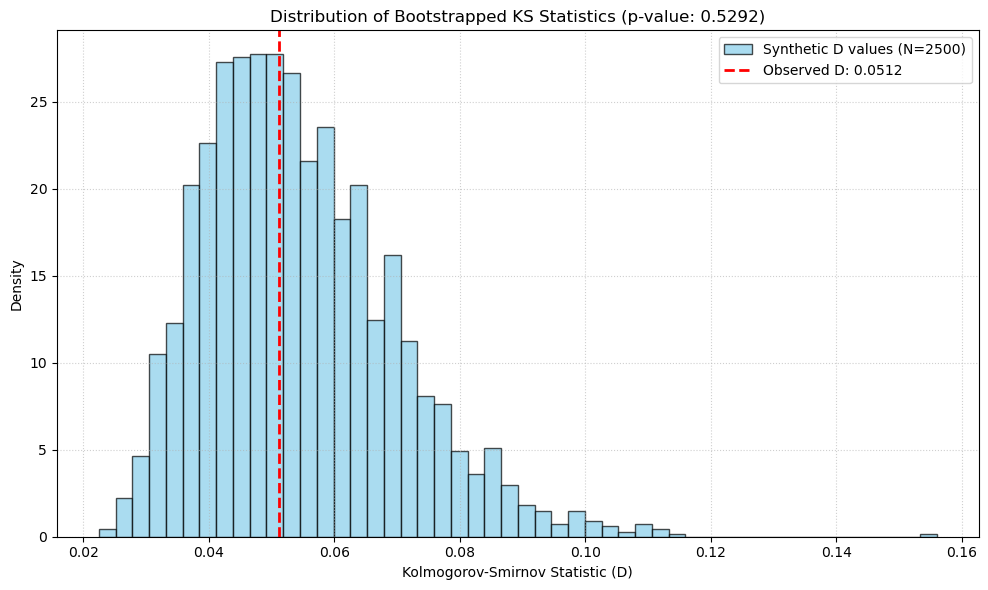

In [102]:
p_value_gof, synthetic_D_values = calculate_powerlaw_gof_p_value(non_zero_revenue, fit, num_bootstraps=2500, discrete=False, seed=42)
observed_D = fit.power_law.D

plt.figure(figsize=(10, 6))
plt.hist(synthetic_D_values, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black', label=f'Synthetic D values (N={len(synthetic_D_values)})')
plt.axvline(observed_D, color='red', linestyle='dashed', linewidth=2, label=f'Observed D: {observed_D:.4f}')
plt.title(f'Distribution of Bootstrapped KS Statistics (p-value: {p_value_gof:.4f})')
plt.xlabel('Kolmogorov-Smirnov Statistic (D)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [104]:
# --- 5. Likelihood Ratio Tests (Comparison with Alternatives) ---
print("\n--- Step 5: Likelihood Ratio Tests (Power Law vs. Alternatives) ---")

print("\n--- Power Law vs. Log-Normal ---")
R_ln, p_ln = fit.distribution_compare('power_law', 'lognormal')
print(f"R (Power Law vs. Log-Normal): {R_ln:.4f}, p-value: {p_ln:.4f}")
if p_ln < 0.1:
    if R_ln > 0: print("  Interpretation: Power Law is a significantly better fit than Log-Normal.")
    else: print("  Interpretation: Log-Normal is a significantly better fit than Power Law.")
else: print("  Interpretation: No significant difference between Power Law and Log-Normal (cannot favor one).")

print("\n--- Power Law vs. Exponential ---")
R_exp, p_exp = fit.distribution_compare('power_law', 'exponential')
print(f"R (Power Law vs. Exponential): {R_exp:.4f}, p-value: {p_exp:.4f}")
if p_exp < 0.1:
    if R_exp > 0: print("  Interpretation: Power Law is a significantly better fit than Exponential.")
    else: print("  Interpretation: Exponential is a significantly better fit than Power Law (unlikely for fat tail).")
else: print("  Interpretation: No significant difference between Power Law and Exponential.")

print("\n--- Power Law vs. Stretched Exponential ---")
R_strexp, p_strexp = fit.distribution_compare('power_law', 'stretched_exponential')
print(f"R (Power Law vs. Stretched Exponential): {R_strexp:.4f}, p-value: {p_strexp:.4f}")
if p_strexp < 0.1:
    if R_strexp > 0: print("  Interpretation: Power Law is a significantly better fit than Stretched Exponential.")
    else: print("  Interpretation: Stretched Exponential is a significantly better fit than Power Law.")
else: print("  Interpretation: No significant difference between Power Law and Stretched Exponential.")




--- Step 5: Likelihood Ratio Tests (Power Law vs. Alternatives) ---

--- Power Law vs. Log-Normal ---
R (Power Law vs. Log-Normal): -1.3056, p-value: 0.3988
  Interpretation: No significant difference between Power Law and Log-Normal (cannot favor one).

--- Power Law vs. Exponential ---
R (Power Law vs. Exponential): 113.2983, p-value: 0.0289
  Interpretation: Power Law is a significantly better fit than Exponential.

--- Power Law vs. Stretched Exponential ---
R (Power Law vs. Stretched Exponential): -1.2821, p-value: 0.4024
  Interpretation: No significant difference between Power Law and Stretched Exponential.


<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_36611/3947756448.py:11: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('P($X \geq x$)')


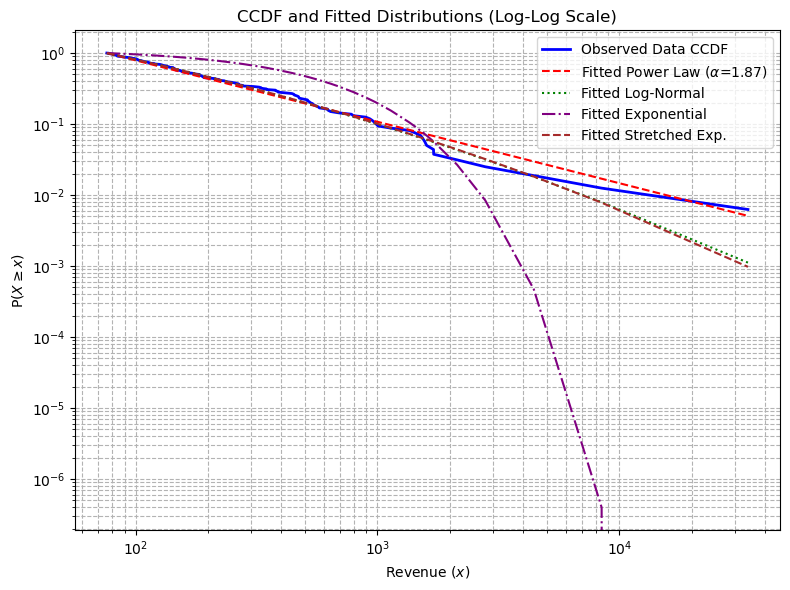

In [105]:
# Visualizing the best fit from alternatives
plt.figure(figsize=(8, 6))
fit.plot_ccdf(ax=plt.gca(), linewidth=2, color='blue', label='Observed Data CCDF')
fit.power_law.plot_ccdf(ax=plt.gca(), linestyle='--', color='red', label=f'Fitted Power Law ($\\alpha$={alpha:.2f})')
fit.lognormal.plot_ccdf(ax=plt.gca(), linestyle=':', color='green', label='Fitted Log-Normal')
fit.exponential.plot_ccdf(ax=plt.gca(), linestyle='-.', color='purple', label='Fitted Exponential')
fit.stretched_exponential.plot_ccdf(ax=plt.gca(), linestyle='--', color='brown', label='Fitted Stretched Exp.')

plt.title('CCDF and Fitted Distributions (Log-Log Scale)')
plt.xlabel('Revenue ($x$)')
plt.ylabel('P($X \geq x$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()


--- Step 6: Hill Estimator and Hill Plot ---


<>:37: SyntaxWarning: invalid escape sequence '\g'
<>:38: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\h'
<>:37: SyntaxWarning: invalid escape sequence '\g'
<>:38: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\h'
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_36611/1312102779.py:37: SyntaxWarning: invalid escape sequence '\g'
  plt.axhline(y=1.0, color='red', linestyle='--', label='$\gamma=1$ ($\\alpha=2$, Infinite Variance)')
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_36611/1312102779.py:38: SyntaxWarning: invalid escape sequence '\g'
  plt.axhline(y=0.5, color='green', linestyle=':', label='$\gamma=0.5$ ($\\alpha=3$, Finite Skewness)') # For reference
/var/folders/x3/z5cc46r95bz2yf3v104lyh8h0000gn/T/ipykernel_36611/1312102779.py:42: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Hill Estimator ($\hat{\gamma}_k$)')


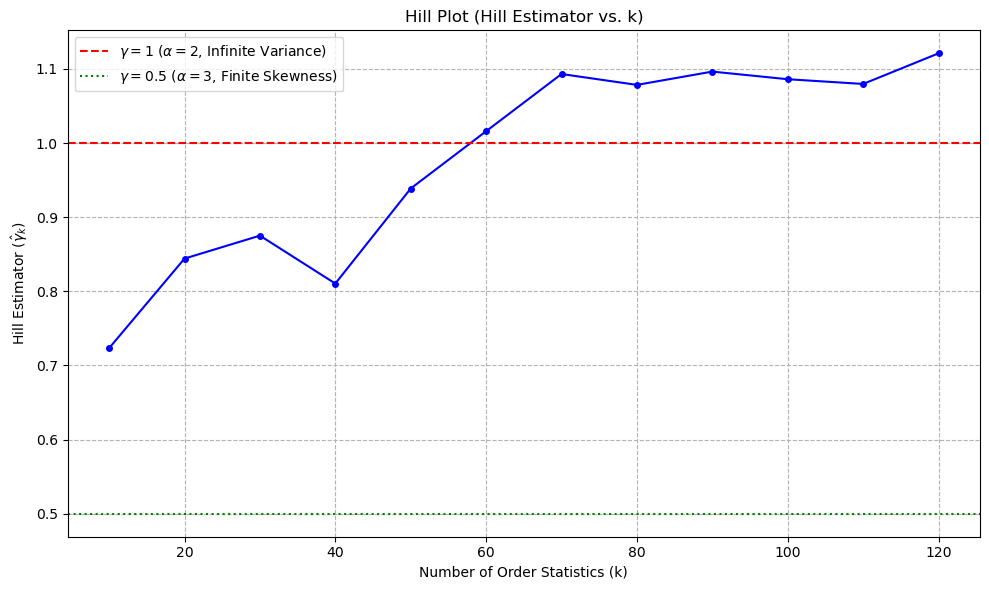


Equivalent gamma from powerlaw.Fit alpha (1.8655): 1.1554

--- Interpretation of Hill Plot ---
Look for a plateau in the Hill plot:
  - If the plateau is consistently above or around 1, it suggests infinite variance (gamma greater or equal than 1 implies alpha smaller or equal than 2).
  - If the plateau is consistently below 1 (e.g., around 0.5 for alpha=3), it suggests finite variance.
  - The stability of the estimate over a range of k indicates robustness.
Note: For data not truly power-law, the Hill plot might not show a clear plateau.


In [106]:
# --- Hill Estimator and Hill Plot ---
print("\n--- Step 6: Hill Estimator and Hill Plot ---")

# Ensure data is sorted in descending order
sorted_non_zero_revenue = np.sort(non_zero_revenue)[::-1]
n = len(sorted_non_zero_revenue)

# Define a range for k.
# k usually ranges from a small number (e.g., 10 or 0.5% of data)
# up to N/2 or N/3, but not too close to N due to bias.
# A common starting range is from 10 to sqrt(N) or N/10 for initial visualization.
k_values = np.arange(10, int(n/3) + 1, 10) # From 10 to 20% of data, step 10

if len(k_values) == 0:
    print("Not enough data points or k_values range to compute Hill plot.")
else:
    hill_estimates = []
    for k in k_values:
        if k + 1 <= n: # Ensure X_(k+1) exists
            # Using the formula: (1/k) * sum(log(X_i) - log(X_k+1))
            # Where X_i are the k largest values, and X_k+1 is the (k+1)-th largest
            term1 = np.sum(np.log(sorted_non_zero_revenue[:k])) / k
            term2 = np.log(sorted_non_zero_revenue[k]) # Note: Python indexing is 0-based, so k-th element is X_(k+1)
            hill_gamma = term1 - term2
            hill_estimates.append(hill_gamma)
        else:
            hill_estimates.append(np.nan) # Mark as NaN if k+1 out of bounds

    # Convert to numpy array for easier plotting
    hill_estimates = np.array(hill_estimates)

    # Plot the Hill Plot
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, hill_estimates, marker='o', linestyle='-', markersize=4, color='blue')

    # Add a horizontal line at gamma = 1 (alpha = 2) for variance check
    plt.axhline(y=1.0, color='red', linestyle='--', label='$\gamma=1$ ($\\alpha=2$, Infinite Variance)')
    plt.axhline(y=0.5, color='green', linestyle=':', label='$\gamma=0.5$ ($\\alpha=3$, Finite Skewness)') # For reference

    plt.title('Hill Plot (Hill Estimator vs. k)')
    plt.xlabel('Number of Order Statistics (k)')
    plt.ylabel('Hill Estimator ($\hat{\gamma}_k$)')
    # plt.xscale('log') # Can also plot k on log scale, sometimes makes plateau clearer
    plt.grid(True, which="both", ls="--", c='0.7')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Find the Hill estimate corresponding to powerlaw's alpha (gamma = 1/(alpha - 1))
    gamma_from_powerlaw_alpha = 1 / (alpha - 1) if alpha > 1 else np.inf
    print(f"\nEquivalent gamma from powerlaw.Fit alpha ({alpha:.4f}): {gamma_from_powerlaw_alpha:.4f}")

    # Interpretation
    print("\n--- Interpretation of Hill Plot ---")
    print("Look for a plateau in the Hill plot:")
    print("  - If the plateau is consistently above or around 1, it suggests infinite variance (gamma greater or equal than 1 implies alpha smaller or equal than 2).")
    print("  - If the plateau is consistently below 1 (e.g., around 0.5 for alpha=3), it suggests finite variance.")
    print("  - The stability of the estimate over a range of k indicates robustness.")
    print("Note: For data not truly power-law, the Hill plot might not show a clear plateau.")